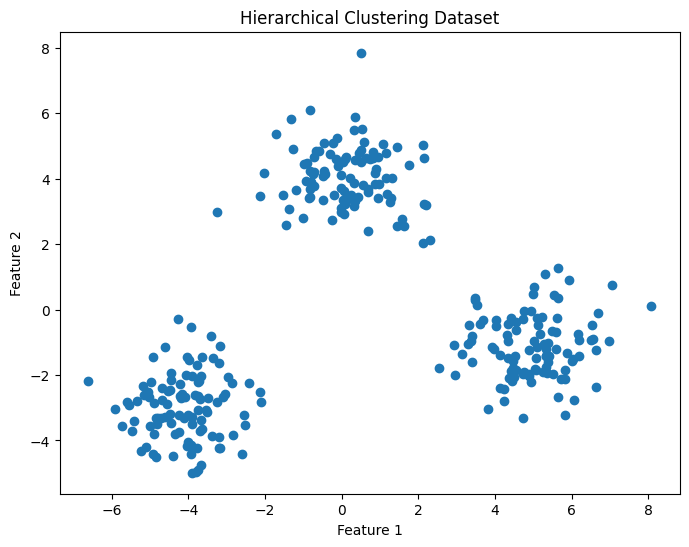

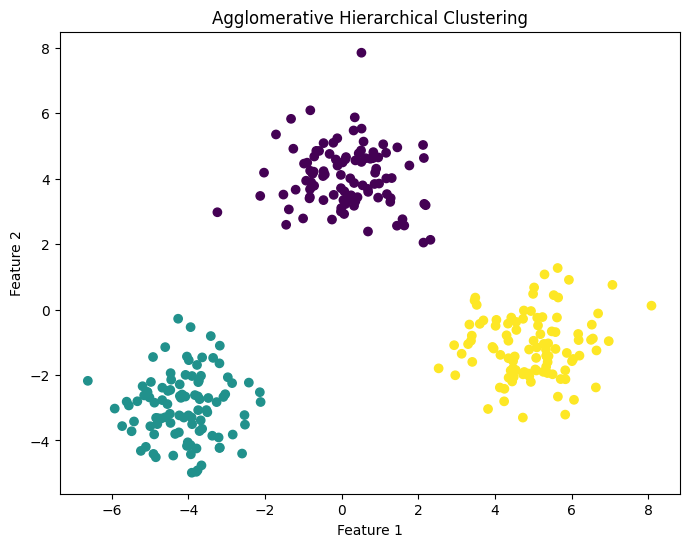

single clusters: [0 1 2]
complete clusters: [0 1 2]
average clusters: [0 1 2]
ward clusters: [0 1 2]


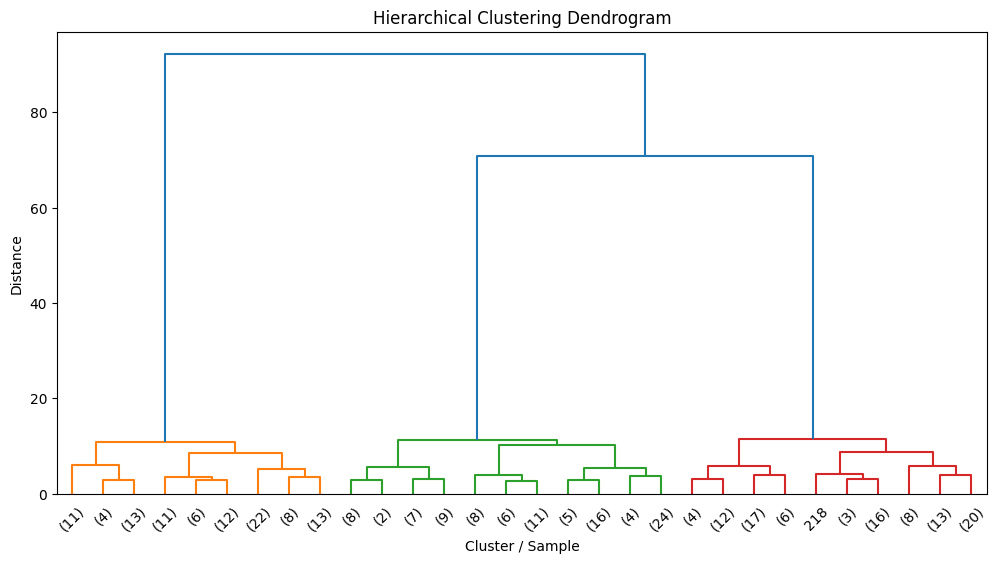


Number of clusters from threshold: 7


In [1]:
# ============================================================
# HIERARCHICAL CLUSTERING 🟢
# ============================================================
#
# DEPTH:
#   🟢 Concept + sklearn
#
# Learn:
#   1. Why Hierarchical Clustering?
#   2. Intuition
#   3. Agglomerative vs Divisive
#   4. Dendrogram
#   5. Linkage
#   6. Internal working
#   7. Distance calculations
#   8. sklearn implementation
#   9. Important parameters
#  10. Choosing number of clusters
#  11. Dendrogram
#  12. Compare with K-Means
#  13. Compare with DBSCAN
#  14. Interview questions
#  15. Working tree
#
# ============================================================


# ============================================================
# 1. IMPORTS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs

from sklearn.cluster import AgglomerativeClustering

from scipy.cluster.hierarchy import (
    dendrogram,
    linkage
)


# ============================================================
# 2. WHY HIERARCHICAL CLUSTERING?
# ============================================================
#
# K-Means requires us to decide K first.
#
# Hierarchical Clustering takes a different approach:
#
#     Build a hierarchy of clusters.
#
#
# The hierarchy can be visualized using a:
#
#     DENDROGRAM
#
#
# Example:
#
#
#             ┌───────────────┐
#             │               │
#          ┌──┴──┐          ┌─┴─┐
#          │     │          │   │
#         A B    C D        E   F
#
#
# We can then "cut" this tree at different heights
# to obtain different numbers of clusters.
#
# ============================================================


# ============================================================
# 3. CORE INTUITION ⭐⭐⭐
# ============================================================
#
# Imagine 6 points:
#
#
#     A  B
#
#              C
#
#
#                       D  E
#
#                              F
#
#
# Initially:
#
#     A = cluster
#     B = cluster
#     C = cluster
#     D = cluster
#     E = cluster
#     F = cluster
#
#
# Then repeatedly merge the closest clusters.
#
#
# Eventually:
#
#     A+B
#     C
#     D+E
#     F
#
#
# Then:
#
#     A+B+C
#     D+E+F
#
#
# Eventually:
#
#     A+B+C+D+E+F
#
#
# This creates a hierarchy.
#
# ============================================================


# ============================================================
# 4. TWO TYPES OF HIERARCHICAL CLUSTERING
# ============================================================
#
#
# ------------------------------------------------------------
# A. Agglomerative
# ------------------------------------------------------------
#
# Bottom-up.
#
# Start:
#
#     Every point is its own cluster.
#
# Then:
#
#     Merge closest clusters.
#
#
# Continue until everything becomes one cluster.
#
#
# This is the approach most commonly used in practice.
#
#
# ------------------------------------------------------------
# B. Divisive
# ------------------------------------------------------------
#
# Top-down.
#
# Start:
#
#     All points are one cluster.
#
# Then repeatedly split clusters.
#
#
# In practice, when people say "Hierarchical Clustering",
# they often mean Agglomerative Clustering.
#
# ============================================================


# ============================================================
# 5. AGGLOMERATIVE WORKING ⭐⭐⭐
# ============================================================
#
#
# STEP 1:
#
# Every point is its own cluster.
#
#
#       A   B   C   D   E
#
#
# STEP 2:
#
# Find the closest pair.
#
#
#       A+B   C   D   E
#
#
# STEP 3:
#
# Find the closest clusters.
#
#
#       A+B   C   D+E
#
#
# STEP 4:
#
# Continue merging.
#
#
#       A+B+C   D+E
#
#
# STEP 5:
#
#       A+B+C+D+E
#
#
# The entire sequence of merges forms the hierarchy.
#
# ============================================================


# ============================================================
# 6. WHAT IS A DENDROGRAM? ⭐⭐⭐
# ============================================================
#
# A dendrogram is a tree showing the order in which clusters
# were merged.
#
#
# Example:
#
#
# Distance
#
#   8 |              ┌───────────────┐
#     |              │               │
#   6 |       ┌──────┴──────┐        │
#     |       │             │        │
#   4 |    ┌──┴──┐        ┌─┴─┐      │
#     |    │     │        │   │      │
#   2 |    A     B        C   D      E
#     |
#     +--------------------------------
#
#
# The height where two branches merge represents the
# distance at which they were joined.
#
#
# Large vertical gap:
#
#     potentially useful place to cut the tree.
#
# ============================================================


# ============================================================
# 7. LINKAGE ⭐⭐⭐
# ============================================================
#
# The important question is:
#
#     "How do we measure the distance between TWO CLUSTERS?"
#
#
# This is determined by LINKAGE.
#
#
# Common linkage methods:
#
#
# 1. SINGLE
#
# Distance between two clusters =
#
#     minimum distance between any two points.
#
#
#     Cluster A: ● ● ●
#     Cluster B:          ● ● ●
#
#     Find closest pair.
#
#
# ------------------------------------------------------------
#
# 2. COMPLETE
#
# Distance =
#
#     maximum distance between any two points.
#
#
# ------------------------------------------------------------
#
# 3. AVERAGE
#
# Distance =
#
#     average pairwise distance between points
#     in the two clusters.
#
#
# ------------------------------------------------------------
#
# 4. WARD ⭐
#
# Merges clusters while minimizing the increase in
# within-cluster variance.
#
#
# Ward is closely related to the idea of minimizing
# within-cluster squared error.
#
# ============================================================


# ============================================================
# 8. LINKAGE INTUITION
# ============================================================
#
#
# SINGLE:
#
#     "Are ANY points close?"
#
#
# COMPLETE:
#
#     "Are ALL points reasonably close?"
#
#
# AVERAGE:
#
#     "What is the average distance?"
#
#
# WARD:
#
#     "Which merge causes the smallest increase in
#      within-cluster variance?"
#
# ============================================================


# ============================================================
# 9. CREATE DATASET
# ============================================================

X, true_labels = make_blobs(
    n_samples=300,
    centers=[
        [-4, -3],
        [0, 4],
        [5, -1]
    ],
    cluster_std=1.0,
    random_state=42
)


# ============================================================
# 10. VISUALIZE DATA
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1]
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title(
    "Hierarchical Clustering Dataset"
)

plt.show()


# ============================================================
# 11. BASIC AGGLOMERATIVE CLUSTERING
# ============================================================
#
# n_clusters:
#
#     Number of clusters we want after cutting the hierarchy.
#
#
# linkage:
#
#     How distance between clusters is calculated.
#
# ============================================================

model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

labels = model.fit_predict(X)


# ============================================================
# 12. VISUALIZE CLUSTERS
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title(
    "Agglomerative Hierarchical Clustering"
)

plt.show()


# ============================================================
# 13. IMPORTANT PARAMETERS
# ============================================================
#
#
# ------------------------------------------------------------
# n_clusters ⭐⭐⭐
# ------------------------------------------------------------
#
# Number of clusters to return.
#
#
# Example:
#
#     n_clusters=3
#
# gives 3 final clusters.
#
#
# ------------------------------------------------------------
# linkage ⭐⭐⭐
# ------------------------------------------------------------
#
# How cluster-to-cluster distance is calculated.
#
# Options commonly used:
#
#     "ward"
#     "complete"
#     "average"
#     "single"
#
#
# IMPORTANT:
#
# Ward works with Euclidean distance.
#
#
# ------------------------------------------------------------
# metric ⭐⭐
# ------------------------------------------------------------
#
# Distance metric.
#
# Examples:
#
#     "euclidean"
#     "manhattan"
#     "cosine"
#
#
# The available combinations depend on the linkage method
# and sklearn version.
#
#
# ------------------------------------------------------------
# distance_threshold ⭐⭐
# ------------------------------------------------------------
#
# Instead of explicitly specifying n_clusters, we can specify
# a distance threshold at which merging should stop.
#
#
# Example concept:
#
#     Merge clusters while distance < threshold.
#
#
# This allows the hierarchy to determine the resulting
# number of clusters.
#
#
# ------------------------------------------------------------
# compute_distances
# ------------------------------------------------------------
#
# If True, distances between merged clusters are stored.
#
# Useful for inspecting the hierarchy.
#
# ============================================================


# ============================================================
# 14. DIFFERENT LINKAGE METHODS
# ============================================================

linkage_methods = [
    "single",
    "complete",
    "average",
    "ward"
]

for method in linkage_methods:

    if method == "ward":

        model = AgglomerativeClustering(
            n_clusters=3,
            linkage=method
        )

    else:

        model = AgglomerativeClustering(
            n_clusters=3,
            linkage=method,
            metric="euclidean"
        )

    labels = model.fit_predict(X)

    print(
        method,
        "clusters:",
        np.unique(labels)
    )


# ============================================================
# 15. DENDROGRAM ⭐⭐⭐
# ============================================================
#
# scipy's linkage() creates the hierarchical merge structure.
#
# It is useful for VISUALIZING the hierarchy.
#
#
# Important:
#
# This is for understanding/visualization.
#
# sklearn's AgglomerativeClustering is commonly used for
# actually fitting the clustering model.
#
# ============================================================

Z = linkage(
    X,
    method="ward"
)


# ============================================================
# 16. PLOT DENDROGRAM
# ============================================================

plt.figure(figsize=(12, 6))

dendrogram(
    Z,
    truncate_mode="lastp",
    p=30
)

plt.xlabel(
    "Cluster / Sample"
)

plt.ylabel(
    "Distance"
)

plt.title(
    "Hierarchical Clustering Dendrogram"
)

plt.show()


# ============================================================
# 17. HOW TO READ THE DENDROGRAM ⭐⭐⭐
# ============================================================
#
# Suppose the dendrogram looks conceptually like:
#
#
# Distance
#
#  10 |              ┌───────────────┐
#     |              │               │
#   8 |              │               │
#     |        ┌─────┴─────┐         │
#   6 |        │           │         │
#     |     ┌──┴──┐      ┌─┴─┐       │
#   4 |     │     │      │   │       │
#     |     A     B      C   D       E
#
#
# Imagine drawing a horizontal line at:
#
#     distance = 5
#
#
# Every branch below that line is one cluster.
#
#
# Therefore:
#
#     Horizontal cut
#             ↓
#     Number of connected groups
#             ↓
#     Number of clusters
#
# ============================================================


# ============================================================
# 18. CUTTING THE DENDROGRAM
# ============================================================
#
# Conceptually:
#
#
#                  hierarchy
#                      │
#                      │
#       ───────────────┼────────────
#              cut here
#                      │
#              ┌───────┴───────┐
#              │               │
#          Cluster 1       Cluster 2
#
#
# Different cut heights produce different numbers of clusters.
#
# ============================================================


# ============================================================
# 19. DISTANCE THRESHOLD
# ============================================================
#
# Instead of:
#
#     n_clusters=3
#
# we can use:
#
#     distance_threshold
#
#
# Then we do not specify n_clusters.
#
# ============================================================

threshold_model = AgglomerativeClustering(
    n_clusters=None,
    distance_threshold=10,
    linkage="ward"
)

threshold_labels = threshold_model.fit_predict(X)

print(
    "\nNumber of clusters from threshold:",
    len(np.unique(threshold_labels))
)


# ============================================================
# 20. WHY HIERARCHICAL CLUSTERING IS DIFFERENT FROM K-MEANS
# ============================================================
#
#
# K-MEANS:
#
#     Choose K
#       ↓
#     Find centroids
#       ↓
#     Assign points
#       ↓
#     Update centroids
#
#
# Hierarchical:
#
#     Start with individual clusters
#       ↓
#     Find closest clusters
#       ↓
#     Merge
#       ↓
#     Repeat
#       ↓
#     Build hierarchy
#
#
# Main conceptual difference:
#
# K-Means gives a flat partition.
#
# Hierarchical clustering gives a hierarchy/tree of
# relationships.
#
# ============================================================


# ============================================================
# 21. K-MEANS vs HIERARCHICAL
# ============================================================
#
# | Property            | K-Means            | Hierarchical |
# |---------------------|--------------------|--------------|
# | Type                | Unsupervised       | Unsupervised |
# | Main idea           | Centroids          | Merge/split  |
# | Need K?             | Yes                | Can use cut  |
# | Output              | Flat clusters      | Hierarchy    |
# | Dendrogram          | No                 | Yes          |
# | Centroid based      | Yes                | No           |
# | Large datasets      | Usually faster     | More costly  |
# | Initialization      | Important          | No centroid  |
#
#
# ============================================================


# ============================================================
# 22. HIERARCHICAL vs DBSCAN
# ============================================================
#
# HIERARCHICAL:
#
#     Builds hierarchy based on distances/linkage.
#
#
# DBSCAN:
#
#     Finds dense regions.
#
#
# HIERARCHICAL:
#
#     Can represent nested relationships.
#
#
# DBSCAN:
#
#     Can explicitly identify noise points.
#
#
# DBSCAN does not require specifying the number of clusters.
#
# ============================================================


# ============================================================
# 23. WHEN TO USE HIERARCHICAL CLUSTERING
# ============================================================
#
# Useful when:
#
#     1. Dataset is not extremely large.
#
#     2. You want to understand relationships between groups.
#
#     3. You want a hierarchy of clusters.
#
#     4. A dendrogram is useful for exploration.
#
#     5. You don't want to commit immediately to one K.
#
#
# Examples:
#
#     Customer segmentation
#     Document clustering
#     Gene expression analysis
#     Taxonomy / grouping
#     Exploratory data analysis
#
# ============================================================


# ============================================================
# 24. LIMITATIONS
# ============================================================
#
# 1. Can be computationally expensive for large datasets.
#
# 2. Sensitive to distance metric.
#
# 3. Sensitive to linkage method.
#
# 4. Once two clusters are merged, the decision generally
#    cannot be undone in standard agglomerative clustering.
#
# 5. Feature scaling can matter because distance is involved.
#
# ============================================================


# ============================================================
# 25. FEATURE SCALING
# ============================================================
#
# Like K-Means, hierarchical clustering often uses distances.
#
# Therefore:
#
#     Feature scaling can be important.
#
#
# Example:
#
#     Age       → 20 to 60
#     Salary    → 20,000 to 200,000
#
#
# Salary can dominate Euclidean distance.
#
#
# StandardScaler can be used when appropriate.
#
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

scaled_model = AgglomerativeClustering(
    n_clusters=3,
    linkage="ward"
)

scaled_labels = scaled_model.fit_predict(
    X_scaled
)


# ============================================================
# 26. INTERVIEW QUESTIONS
# ============================================================
#
#
# Q1. What is hierarchical clustering?
#
# Answer:
#
# It is an unsupervised clustering technique that builds
# a hierarchy of nested clusters by repeatedly merging
# or splitting clusters.
#
#
# ------------------------------------------------------------
#
# Q2. What is agglomerative clustering?
#
# Answer:
#
# It is bottom-up hierarchical clustering. Every point starts
# as its own cluster, and the closest clusters are repeatedly
# merged.
#
#
# ------------------------------------------------------------
#
# Q3. What is a dendrogram?
#
# Answer:
#
# A tree-like visualization showing the sequence and distance
# of cluster merges.
#
#
# ------------------------------------------------------------
#
# Q4. What is linkage?
#
# Answer:
#
# Linkage defines how the distance between two clusters is
# calculated.
#
#
# ------------------------------------------------------------
#
# Q5. Explain single linkage.
#
# Answer:
#
# Distance between two clusters is the minimum distance
# between any pair of points from the two clusters.
#
#
# ------------------------------------------------------------
#
# Q6. Explain complete linkage.
#
# Answer:
#
# Distance is based on the maximum pairwise distance between
# points in the two clusters.
#
#
# ------------------------------------------------------------
#
# Q7. What is Ward linkage?
#
# Answer:
#
# It chooses merges that minimize the increase in
# within-cluster variance.
#
#
# ------------------------------------------------------------
#
# Q8. K-Means vs hierarchical?
#
# Answer:
#
# K-Means creates a flat partition using centroids, while
# hierarchical clustering builds a hierarchy of nested
# clusters that can be visualized with a dendrogram.
#
#
# ------------------------------------------------------------
#
# Q9. Can hierarchical clustering work without specifying K?
#
# Answer:
#
# Yes. You can construct the hierarchy first and choose the
# number of clusters by cutting the dendrogram at a chosen
# distance.
#
#
# ------------------------------------------------------------
#
# Q10. What is the difference between agglomerative and
# divisive clustering?
#
# Answer:
#
# Agglomerative is bottom-up: repeatedly merge clusters.
#
# Divisive is top-down: repeatedly split clusters.
#
#
# ============================================================
# 27. 30-SECOND INTERVIEW EXPLANATION
# ============================================================
#
# Hierarchical clustering is an unsupervised algorithm that
# builds a hierarchy of clusters.
#
# In the common agglomerative approach, every point starts
# as its own cluster. We repeatedly find the closest pair
# of clusters and merge them according to a linkage rule such
# as single, complete, average, or Ward linkage.
#
# The resulting hierarchy can be visualized using a dendrogram,
# and we can choose the final number of clusters by cutting
# the tree at a particular height.
#
# ============================================================


# ============================================================
# 28. MEMORY CHEATSHEET
# ============================================================
#
# HIERARCHICAL CLUSTERING
#
#     Unsupervised
#          ↓
#     Build hierarchy
#          ↓
#     Dendrogram
#          ↓
#     Choose cut
#          ↓
#     Final clusters
#
#
# AGGLOMERATIVE:
#
#     Individual points
#          ↓
#     Find closest clusters
#          ↓
#     Merge
#          ↓
#     Repeat
#
#
# LINKAGE:
#
#     SINGLE   → minimum distance
#
#     COMPLETE → maximum distance
#
#     AVERAGE  → average distance
#
#     WARD     → minimize increase in variance
#
#
# ============================================================
# 29. WORKING TREE ⭐⭐⭐
# ============================================================
#
#
#                  HIERARCHICAL
#                   CLUSTERING
#                       │
#                       ▼
#               Choose distance
#                 + linkage
#                       │
#                       ▼
#              Start with every
#              point as a cluster
#                       │
#                       ▼
#              Find closest pair
#               of clusters
#                       │
#                       ▼
#                    MERGE
#                       │
#                       ▼
#              Update cluster
#                relationships
#                       │
#                       ▼
#              Repeat until one
#              hierarchy remains
#                       │
#                       ▼
#                  DENDROGRAM
#                       │
#                       ▼
#                  Choose cut
#                       │
#                       ▼
#                Final clusters
#
#
# ============================================================
#
# ONE-LINE MENTAL MODEL:
#
#     "Start with every point alone, repeatedly merge the
#      closest clusters, and build a tree that lets us cut
#      the hierarchy into the groups we want."
#
# ============================================================